# 示例策略3: 集合竞价选股策略

本策略通过获取SHSE.000300沪深300的成份股数据并统计其30天内开盘价大于前收盘价的天数,并在该天数大于阈值10的时候加入股票池,随后对不在股票池的股票平仓并等权配置股票池的标的,每次交易间隔1个月.

回测数据为:SHSE.000300沪深300指数成份股
回测时间为:2016-04-05 到 2021-02-01

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../..'))
# 导入qteasy模块
import qteasy as qt
print(f'qteasy version: {qt.__version__}, datasource: {qt.QT_DATA_SOURCE}')

qteasy version: 2.2.1, datasource: mysql://www.qteasy.cn@9306/ts_db


In [2]:
htypes = 'open, close'
shares = qt.filter_stock_codes(index='000300.SH', date='20220131')
print(shares[0:10])
dt = qt.get_history_data(htypes, shares=shares, asset_type='any', freq='m')

one_share = shares[24]

df = dt[one_share]

df

['000001.SZ', '000002.SZ', '000063.SZ', '000066.SZ', '000069.SZ', '000100.SZ', '000157.SZ', '000166.SZ', '000301.SZ', '000333.SZ']


,open,close
2025-03-31,28.90,29.10
2025-04-30,29.02,28.02
2025-05-30,28.20,28.67
2025-06-30,28.51,26.48
2025-07-31,26.42,26.09
2025-08-29,26.12,26.70
2025-09-30,26.69,23.66
2025-10-31,23.70,23.77
2025-11-28,23.88,25.31
2025-12-31,25.10,24.97


In [54]:
'''
第一种自定义策略设置方法，使用持仓数据和选股数据直接生成比例交易信号PS信号：
使用GeneralStrategy策略类，计算选股因子后，去掉所有小于零的因子，排序后提取排名前三十的股票
按以下逻辑生成交易信号：
1，检查当前持仓，如果持仓的股票未被选中，则全数卖出
2，检查当前持仓，如果新选中的股票没有持仓，则等权买入新增选中的股票

设置交易信号类型为PS，生成交易信号
由于生成交易信号需要用到持仓数据，因此不能使用批量生成模式，只能使用realtime模式
'''
import numpy as np
class GroupPS(qt.GeneralStg):
    
    def realize(self):
        
        # 读取策略参数（开盘价大于收盘价的天数）
        n_day = self.get_pars('n_day')

        # 从历史数据编码中读取四种历史数据的最新数值
        opens, closes = self.get_data('open_E_d', 'close_E_d')  
        opens = opens[-30:]  # 从前一交易日起前30天内开盘价
        closes = closes[-30:]  # 
        
        # 从持仓数据中读取当前的持仓数量，并找到持仓股序号
        own_amounts = self.get_data('proc.own_amounts')
        owned = np.where(own_amounts > 0)[1]  # 所有持仓股的序号
        not_owned = np.where(own_amounts == 0)[1]  # 所有未持仓的股票序号
        # import pdb; pdb.set_trace()
        # 选股因子为开盘价大于收盘价的天数，使用astype将True/False结果改为1/0，便于加总
        factors = ((opens - closes) > 0).astype('float')
        # 所有开盘价-收盘价>0的结果会被转化为1，其余结果转化为0，因此可以用sum得到开盘价大于收盘价的天数
        factors = factors.sum(axis=0)
        # 选出开盘价大于收盘价天数大于十天的所有股票的序号
        all_args = np.arange(len(factors))
        selected = np.where(factors > n_day)[0]
        not_selected = np.setdiff1d(all_args, selected)
        # 计算选出的股票的数量
        selected_count = len(selected)
        print(f'now {selected_count} shares are selected!')
        
        # 开始生成交易信号
        signal = np.zeros_like(factors)
        # 如果持仓为正，且未被选中，生成全仓卖出交易信号
        own_but_not_selected = np.intersect1d(owned, not_selected)
        signal[own_but_not_selected] = -1  # 在PS信号模式下 -1 代表全仓卖出
        
        if selected_count == 0:
            # 如果选中的数量为0，则不需要生成买入信号，可以直接返回只有卖出的信号
            return signal
        
        # 如果持仓为零，且被选中，生成全仓买入交易信号
        selected_but_not_own = np.intersect1d(not_owned, selected)
        signal[selected_but_not_own] = 1. / selected_count  # 在PS信号模式下，+1 代表全仓买进 （如果多只股票均同时全仓买进，则会根据资金总量平均分配资金）

        return signal

now 1 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 2 shares are selected!
now 1 shares are selected!
now 2 shares are selected!
now 1 shares are selected!
now 3 shares are selected!
now 4 shares are selected!
now 3 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 1 shares are selected!
now 3 shares are selected!
now 3 shares are selected!
now 2 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 1 shares are selected!
now 2 shares are selected!
now 2 shares are selected!
now 1 shares are selected!
now 1 shares are selected!
now 1 shares are selected!
now 0 shares are selected!
now 1 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 1 shares are selected!
now 4 shares are selected!
now 8 shares are selected!
now 5 shares are selected!
n

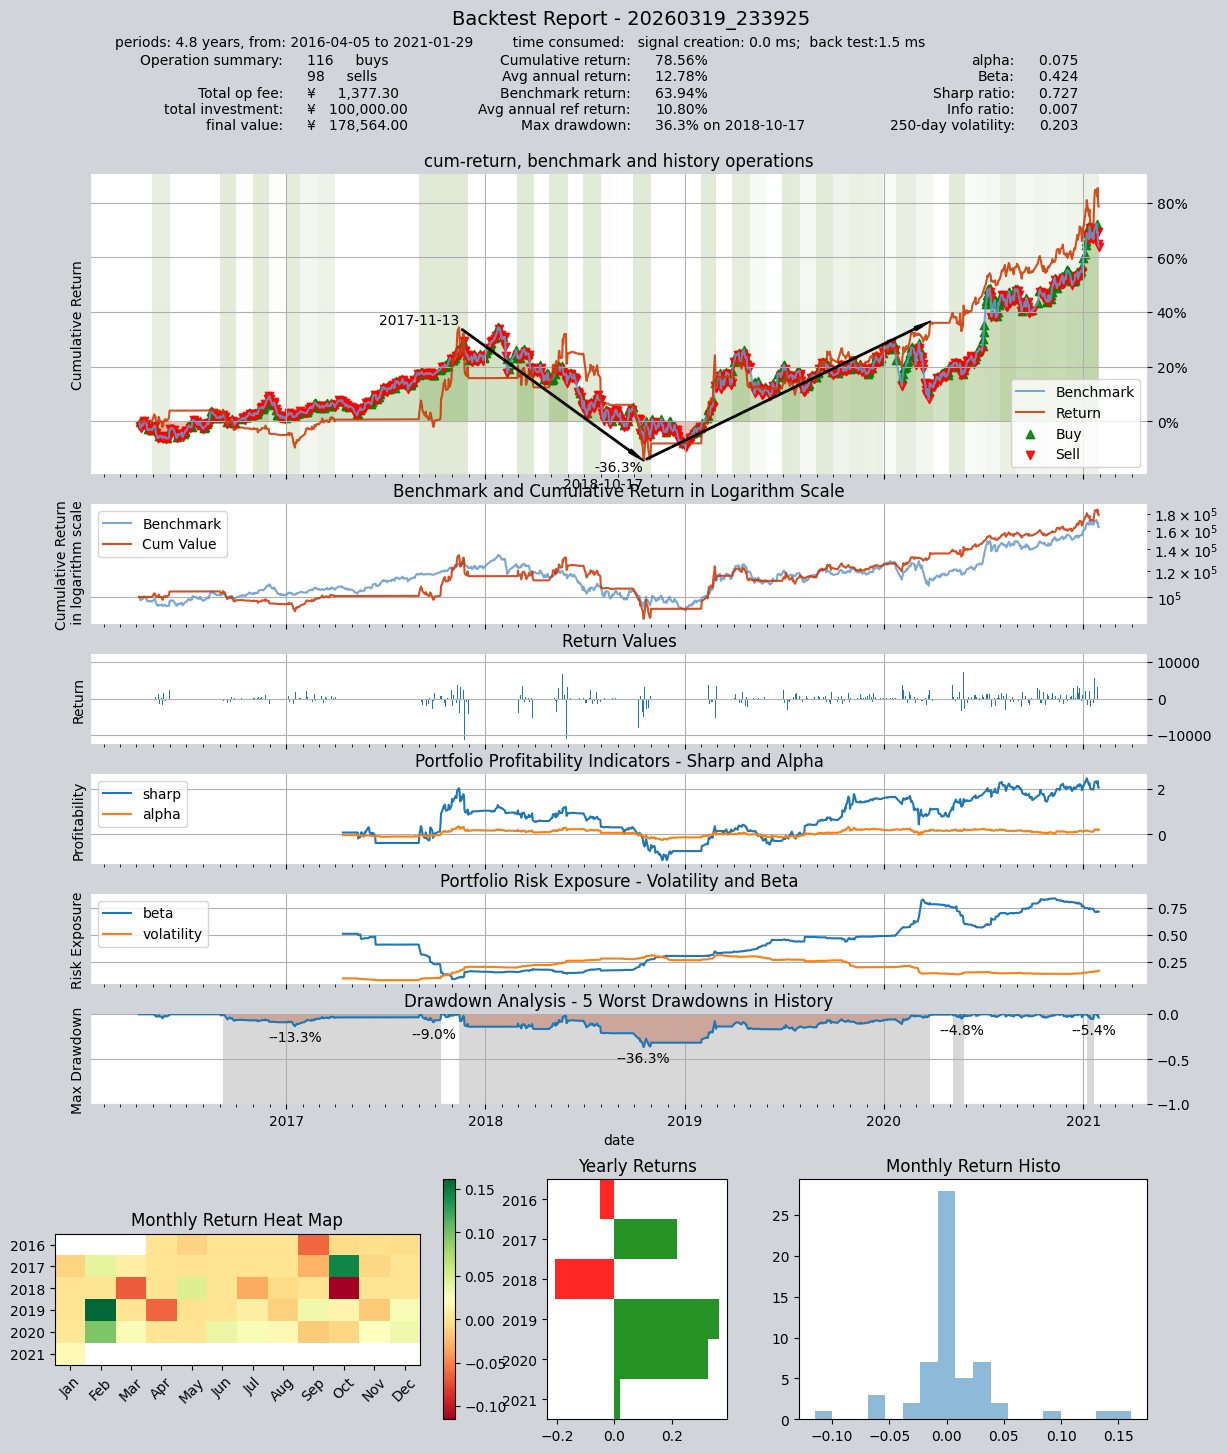

In [55]:
from qteasy import Parameter, StgData
alpha = GroupPS(name='GroupPS',
                description='本策略每隔1个月定时触发, 从SHSE.000300成份股中选择过去30天内开盘价大于前收盘价的天数大于10天的股票买入',
                pars=[Parameter((3, 25), par_type='int', name='n_day', value=10)],
                data_types=[StgData('open', freq='d', asset_type='E', window_length=32), 
                                     StgData('close', freq='d', asset_type='E', window_length=32)],
               )  
op = qt.Operator(alpha, signal_type='PS', run_freq='ME')
op.op_type = 'stepwise'
op.set_parameter(0, par_values=(20,))
qt.run(op=op, mode=1,
       asset_type='E',
       asset_pool=shares,
       invest_start='20160405',
       invest_end='20210201',
       trade_batch_size=100,
       sell_batch_size=1,
       trade_log=True)
print()

In [51]:
'''
第二种自定义策略设置方法：
使用FactorSorter策略类，直接生成交易策略的选股因子，再根据
FactorSorter策略的选股参数实现选股

设置交易信号类型为PT，生成持仓目标，自动生成交易信号
'''
class GroupPT(qt.GeneralStg):
    
    def realize(self):

        # 读取策略参数（开盘价大于收盘价的天数）
        
        # 读取策略参数（开盘价大于收盘价的天数）
        n_day = self.get_pars('n_day')

        # 从历史数据编码中读取四种历史数据的最新数值
        opens, closes = self.get_data('open_E_d', 'close_E_d')  # 从前一交易日起前30天内开盘价
        opens = opens[-30:]
        closes = closes[-30:]
        
        # 选股因子为开盘价大于收盘价的天数，使用astype将True/False结果改为1/0，便于加总
        factors = ((opens - closes) > 0).astype('float')
        # 所有开盘价-收盘价>0的结果会被转化为1，其余结果转化为0，因此可以用sum得到开盘价大于收盘价的天数
        factors = factors.sum(axis=0)
        # import pdb; pdb.set_trace()
        # 选出开盘价大于收盘价天数大于十天的所有股票的序号
        all_args = np.arange(len(factors))
        selected = np.where(factors > n_day)[0]
        not_selected = np.setdiff1d(all_args, selected)
        # 计算选出的股票的数量
        selected_count = len(selected)
        print(f'now {selected_count} shares are selected!')
        
        # 开始生成交易信号
        signal = np.zeros_like(factors)
        if selected_count == 0:
            return signal
        # 所有被选中的股票均设置为正持仓目标
        signal[selected] = 1. / selected_count  
        # 未被选中的股票持仓目标被设置为0
        signal[not_selected] = 0
        
        return signal
    

now 1 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 2 shares are selected!
now 1 shares are selected!
now 2 shares are selected!
now 1 shares are selected!
now 3 shares are selected!
now 4 shares are selected!
now 3 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 1 shares are selected!
now 3 shares are selected!
now 3 shares are selected!
now 2 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 1 shares are selected!
now 2 shares are selected!
now 2 shares are selected!
now 1 shares are selected!
now 1 shares are selected!
now 1 shares are selected!
now 0 shares are selected!
now 1 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 0 shares are selected!
now 1 shares are selected!
now 4 shares are selected!
now 8 shares are selected!
now 5 shares are selected!
n

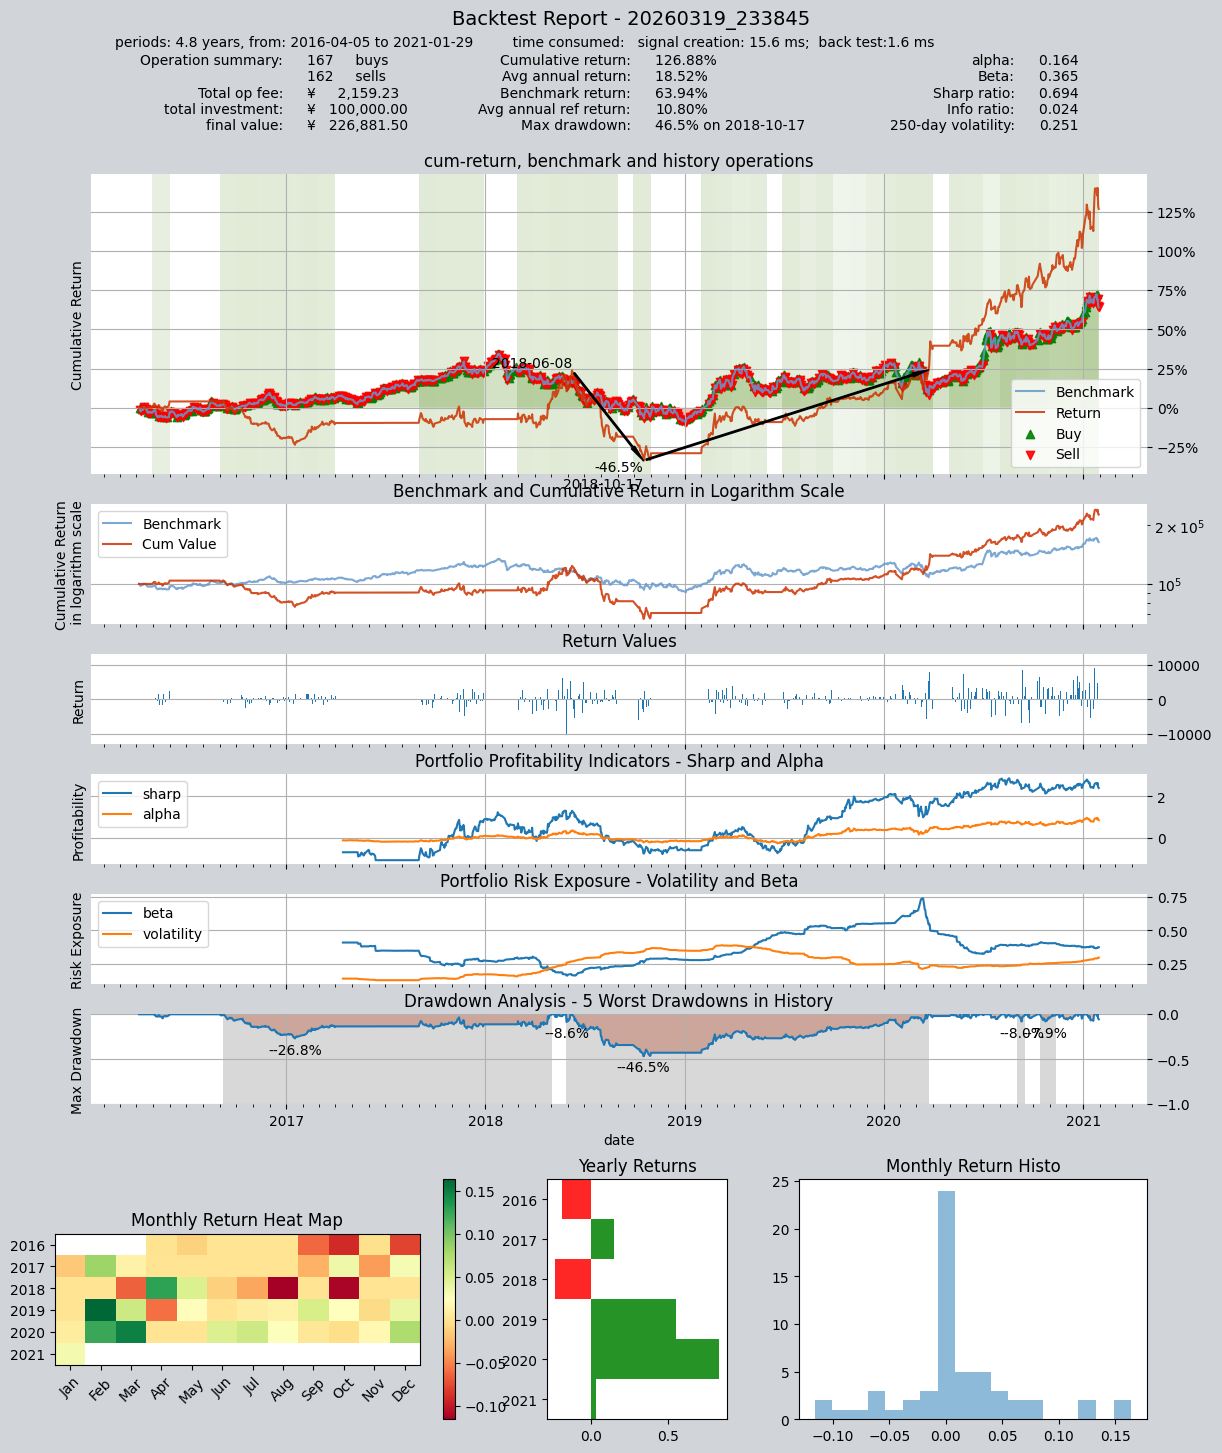

In [53]:
alpha = GroupPT(name='GroupPS',
                description='本策略每隔1个月定时触发, 从SHSE.000300成份股中选择过去30天内开盘价大于前收盘价的天数大于10天的股票买入',
                pars=[Parameter((3, 25), par_type='int', name='n_day', value=10)],
                data_types=[StgData('open', freq='d', asset_type='E', window_length=32), 
                            StgData('close', freq='d', asset_type='E', window_length=32)],
               )  
op = qt.Operator(alpha, signal_type='PT', run_freq='ME')
op.set_parameter(0, par_values=(20,))
qt.run(op=op, mode=1,
       asset_type='E',
       asset_pool=shares,
       invest_start='20160405',
       invest_end='20210201',
       trade_batch_size=100,
       sell_batch_size=1,
       trade_log=True)
print()